# CNO via pynucastro

We can redo the same integration but using pynucastro to manage the integration.  This will allow us to make pretty pictures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "c13",
                           "n13", "n14", "n15",
                           "o14", "o15", "o16", "o17", "o18",
                           "f17", "f18", "f19",
                           "ne18", "ne19", "ne20"], tabular_ordering=["ffn", "oda"])

We'll setup the same initial conditions

In [11]:
rho = 150
T = 1.5e7

In [12]:
comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("p")] = 0.7
comp.X[pyna.Nucleus("he4")] = 0.28
comp.X[pyna.Nucleus("c12")] = 0.02

Y0 = comp.get_molar_array()

Now we can integrate

In [13]:
tmax = 1.e20

In [14]:
sol = net.integrate_network(tmax, rho, T, Y0, atol=1.e-8)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 b

In [15]:
sol.success

True

Now we can plot the mass fractions.

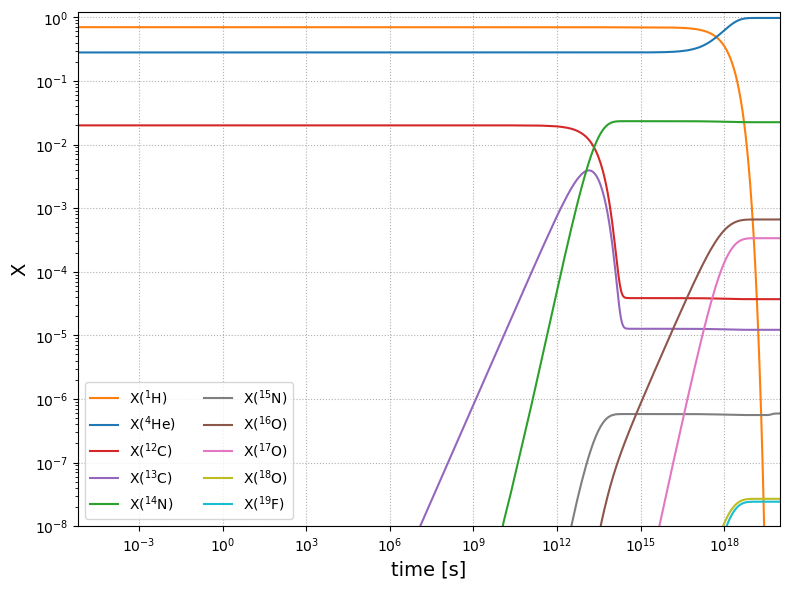

In [17]:
fig = sol.plot_evolution(ymin=1.e-8)

We can also look at the flow through the network

In [24]:
X_final = sol.X[:, -1]
comp_final = pyna.Composition(net.unique_nuclei)
comp_final.set_array(X_final)

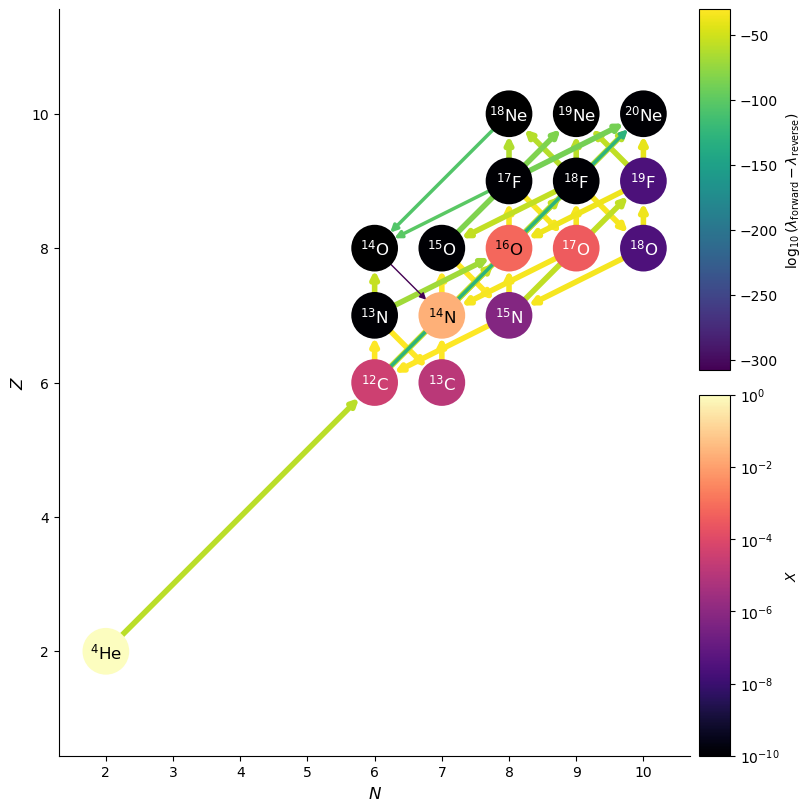

In [28]:
fig = net.plot(rho, T, comp_final,
               size=(800, 800),
               use_net_rate=True, color_nodes_by_abundance=True)